We can start with the same dependencies as in the previous notebooks.

In [1]:
import torch
import random
import torch.nn.functional as F
import matplotlib.pyplot as plt

Create the same dataset from the previous notebook.

In [2]:
words = open("names.txt", "r").read().splitlines()
chars = sorted(list(set("".join(words))))

s_i = {s:i+1 for i, s in enumerate(chars)}
s_i["."] = 0

i_s = {i:s for s, i in s_i.items()}

# building dataset

block_size = 3

def build_dataset(words):
    
    X, Y = [], []
    for w in words:
        # print(w)
        context = [0] * block_size
        
        for ch in w + ".":
            ix = s_i[ch]
            X.append(context)
            Y.append(ix)
            # print("".join(i_s[i] for i in context), "---->", i_s[ix])
            context = context[1:] + [ix]
            
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

To keep the results of this experiment truthful, we implement a simple train, dev, test split, allowing us to easily evaluate our model while avoiding overfitting to our final test data.

Approximately 80% of the dataset is used for training, 10% for validation, and the last 10% for testing.

In [3]:
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

To make manual backpropagation easier, we initialize the parameters manually, rather than using the class-based layer approach from part #3.

We intentionally avoid hardcoding any of the parameter vector sizes, basing them instead on the size of the inputs.

`n_embd` and `n_hidden` also enable us to modify the amount of neurons in each of the two layers.

In [4]:
n_embd = 10 # dimensionality of character embedding vector
n_chars = 27
n_hidden = 200 # number of neurons in hidden layer

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((n_chars, n_embd), generator=g)

w1 = torch.randn((n_embd * block_size, n_hidden)) * (5/3) / (30 ** 0.5) # kaiming initialization
# b1 = torch.randn(n_hidden) * 0.01

w2 = torch.randn((n_hidden, n_chars)) * 0.01
b2 = torch.randn(n_chars) * 0.1

bngain = torch.ones((1, n_hidden)) # * 0.1
bnbias = torch.zeros((1, n_hidden)) # * 0.1

parameters = [C, w1, w2, b2, bngain, bnbias]

for p in parameters:
    p.requires_grad = True

For development purposes, we execute one step of the MLP's forward pass, allowing us to compare the manual backward pass with PyTorch's.

I have also included the functionality for comparing the manual cross-entropy loss calculation with PyTorch's native functionality.

The manual loss calculation consistently achieves very low differences as compared to PyTorch's calculation.

In [ ]:
batch_size = 32
n = batch_size

lossi = []
stepi = []

ix = torch.randint(0, Xtr.shape[0], (batch_size,))
Xb, Yb = Xtr[ix], Ytr[ix]

# forward pass

# linear layer
# --------------------------------------
emb = C[Xb]
embcat = emb.view(-1, 30)
hprebn = embcat @ w1 # + b1
# --------------------------------------

# batch normalization layer (slow)
# --------------------------------------
bnmeani = 1 / n * hprebn.sum(0, keepdim=True)
bndiff = hprebn - bnmeani
bndiff2 = bndiff ** 2
bnvar = 1 / (n - 1) * (bndiff2).sum(0, keepdim=True)
bnvar_inv = (bnvar + 1e-5) ** -0.5
bnraw = bndiff * bnvar_inv

hpreact = bngain * bnraw + bnbias # added an epsilon to bnstdi
# --------------------------------------

# batch normalization layer (fast)
# --------------------------------------
hpreact_fast = bngain * (hprebn - hprebn.mean(0, keepdim=True)) / torch.sqrt(hprebn.var(0, keepdim=True, unbiased=True) + 1e-5) + bnbias
# --------------------------------------

# non-linear layer
# --------------------------------------
h = torch.tanh(hpreact_fast)

logits = h @ w2 + b2
# --------------------------------------

# manual cross entropy-loss
# --------------------------------------
logit_maxes = logits.max(1, keepdim=True).values
norm_logits = logits - logit_maxes
counts = norm_logits.exp()
counts_sum = counts.sum(1, keepdim=True)
counts_sum_inv = counts_sum ** -1
probs = counts * counts_sum_inv
logprobs = probs.log()
loss = -logprobs[range(n), Yb].mean()
# --------------------------------------

# fast cross-entropy loss in PyTorch
# --------------------------------------
loss_fast = F.cross_entropy(logits, Yb)
# --------------------------------------

# fast backward pass in PyTorch
# --------------------------------------
for p in parameters:
    p.grad = None
    
for t in [logprobs, probs, counts, counts_sum, counts_sum_inv,
          norm_logits, logit_maxes, logits, h, hpreact, bnmeani, 
          embcat, emb, bngain, bnraw, bndiff, bnvar, 
          bnvar_inv, hprebn, bndiff2, loss_fast]:
    t.retain_grad()

loss_fast.backward()
# --------------------------------------

print(f"torch: {loss_fast.item()} | manual: {loss} | diff: {(loss_fast - loss).item()}")

torch: 3.284205198287964 | manual: 3.284205436706543 | diff: -2.384185791015625e-07


We use this function to help in comparing the accuracy of each manually-calculated gradient. 

It takes a manual gradient and benchmarks it against PyTorch's `Tensor.backward()` functionality.

The output of this function displays whether the manual gradient was correct, and if not, how much it differed by.

In [8]:
# define comparison function
def cmp(s, dt, t):
    ex = torch.all(dt == t.grad).item()
    app = torch.allclose(dt, t.grad)
    maxdiff = (dt - t.grad).abs().max().item()
    print(f'{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {maxdiff}')

In [14]:
# manual backprop

# --- with manual cross-entropy loss ---
# dlogprobs = torch.zeros_like(logprobs)
# dlogprobs[range(n), Yb] = -1.0 / n
# dprobs = (1.0 / probs) * dlogprobs
# dcounts_sum_inv = (counts * dprobs).sum(1, keepdim=True) # *
# dcounts = counts_sum_inv * dprobs # *
# dcounts_sum = (-counts_sum ** -2) * dcounts_sum_inv
# dcounts += torch.ones_like(counts) * dcounts_sum

# dnorm_logits = dcounts * counts
# dlogits = dnorm_logits.clone()
# dlogit_maxes = (-dnorm_logits).sum(1, keepdim=True) # *

# dlogits += F.one_hot(logits.max(1).indices, num_classes=logits.shape[1]) * dlogit_maxes # *
# --------------------------------------

# with fast cross-entropy loss
# dlogits = -1.0 *  ((torch.ones_like(Yb, dtype=torch.float32)).view(32, 1) * logits.exp())
dlogits = F.softmax(logits, 1)
dlogits[range(n), Yb] -= 1
dlogits /= n

# --------------------------------------

dh = dlogits @ w2.T # *
dw2 = h.T @ dlogits # *
db2 = dlogits.sum(0) # *

dhpreact = (1.0 - (h ** 2)) * dh # *

# dhpreact_fast = bngain

# dbngain = (bnraw * dhpreact).sum(0, keepdim=True) # *
# dbnraw = bngain * dhpreact
# dbnbias = dhpreact.sum(0, keepdim=True) # *

# dbndiff = bnvar_inv * dbnraw
# dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True) # *
# dbnvar = -0.5 * (bnvar_inv ** -1.5) * dbnvar_inv
# dbndiff2 = torch.ones_like(bndiff2) * (1.0 / (n - 1)) * dbnvar
# dbndiff += (2 * bndiff) * dbndiff2
# dhprebn = dbndiff.clone()
# dbnmeani = (-dbndiff).sum(0)

# dhprebn += (1.0 / n) * (torch.ones_like(hprebn) * dbnmeani)
dhprebn = bngain * bnvar_inv / n * (n * dhpreact - dhpreact.sum(0) - n / (n - 1) * bnraw * (dhpreact * bnraw.sum(0)))

dembcat = dhprebn @ w1.T
dw1 = embcat.T @ dhprebn

dC = torch.zeros_like(C)
dC[Xb] = dembcat.view(32, 3, 10)

# cmp("logprobs", dlogprobs, logprobs)
# cmp("probs", dprobs, probs)
# cmp("counts_sum_inv", dcounts_sum_inv, counts_sum_inv)
# cmp("counts_sum", dcounts_sum, counts_sum)
# cmp("counts", dcounts, counts)
# cmp("norm_logits", dnorm_logits, norm_logits)
# cmp("norm_logits", dnorm_logits, norm_logits)
# cmp("logit_maxes", dlogit_maxes, logit_maxes)
cmp("logits", dlogits, logits)
cmp("dh", dh, h)
cmp("dw2", dw2, w2)
cmp("db2", db2, b2)
# cmp("dhpreact", dhpreact, hpreact)
# cmp("dbngain", dbngain, bngain)
# cmp("dbnraw", dbnraw, bnraw)
# cmp("dbnbias", dbnbias, bnbias)
# cmp("dbndiff", dbndiff, bndiff)
# cmp("dbnvar_inv", dbnvar_inv, bnvar_inv)
cmp("dhprebn", dhprebn, hprebn)
# cmp("dbnmeani", dbnmeani, bnmeani)
# cmp("dbnvar", dbnvar, bnvar)
# cmp("dbndiff2", dbndiff2, bndiff2)

cmp("dembact", dembcat, embcat)
cmp("dw1", dw1, w1)
cmp("dC", dC, C)

logits          | exact: False | approximate: True  | maxdiff: 3.4924596548080444e-10
dh              | exact: False | approximate: True  | maxdiff: 1.1641532182693481e-10
dw2             | exact: False | approximate: True  | maxdiff: 7.450580596923828e-09
db2             | exact: False | approximate: True  | maxdiff: 7.450580596923828e-09
dhprebn         | exact: False | approximate: False | maxdiff: 0.00010489291162230074
dembact         | exact: False | approximate: False | maxdiff: 0.0001686315517872572
dw1             | exact: False | approximate: False | maxdiff: 0.0008100682171061635
dC              | exact: False | approximate: False | maxdiff: 0.004724849946796894


We can then visualize the gradients contained in `dlogits`. Darker squares indicate gradients close or equal to zero.

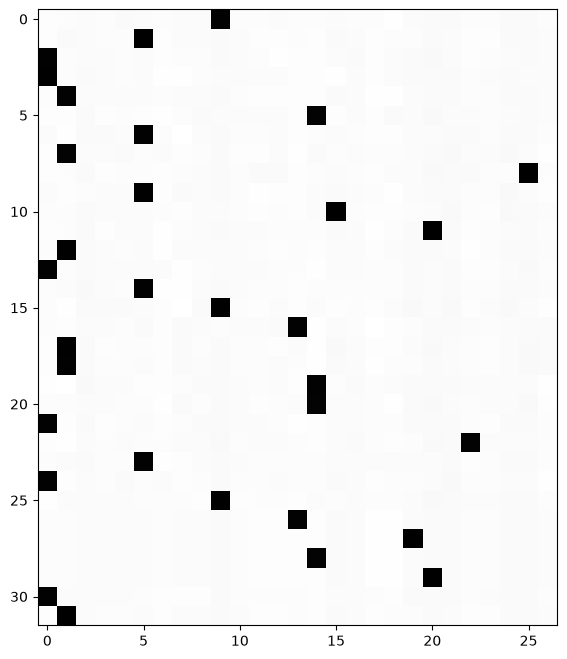

In [95]:
plt.figure(figsize=(8, 8))
plt.imshow(dlogits.detach(), cmap="gray")

Finally, we implement the manual backpropagation into a robust training loop, allowing for the optimization of the language model.

Crucially, this implementation **does not** use PyTorch's `Tensor.backward()` function. Instead, each gradient for each parameter is calculated explicitly, as seen in the cells above.

This results in a much significantly longer training time.

In [ ]:
# training loop

max_steps = 200000

batch_size = 32
n = batch_size

# lossi = []
# stepi = []
with torch.no_grad():
    for i in range(max_steps):
        ix = torch.randint(0, Xtr.shape[0], (batch_size,))
        Xb, Yb = Xtr[ix], Ytr[ix]

        # forward pass

        # linear layer
        # --------------------------------------
        emb = C[Xb]
        embcat = emb.view(-1, 30)
        hprebn = embcat @ w1 # + b1
        # --------------------------------------

        # batch normalization layer (slow)
        # --------------------------------------
        bnmeani = 1 / n * hprebn.sum(0, keepdim=True)
        bndiff = hprebn - bnmeani
        bndiff2 = bndiff ** 2
        bnvar = 1 / (n - 1) * (bndiff2).sum(0, keepdim=True)
        bnvar_inv = (bnvar + 1e-5) ** -0.5
        bnraw = bndiff * bnvar_inv

        hpreact = bngain * bnraw + bnbias # added an epsilon to bnstdi
        # --------------------------------------

        # batch normalization layer (fast)
        # --------------------------------------
        hpreact_fast = bngain * (hprebn - hprebn.mean(0, keepdim=True)) / torch.sqrt(hprebn.var(0, keepdim=True, unbiased=True) + 1e-5) + bnbias
        # --------------------------------------

        # non-linear layer
        # --------------------------------------
        h = torch.tanh(hpreact_fast)

        logits = h @ w2 + b2

        # ----- manual cross-entropy loss ------
        logit_maxes = logits.max(1, keepdim=True).values
        norm_logits = logits - logit_maxes
        counts = norm_logits.exp()
        counts_sum = counts.sum(1, keepdim=True)
        counts_sum_inv = counts_sum ** -1
        probs = counts * counts_sum_inv
        logprobs = probs.log()
        loss = -logprobs[range(n), Yb].mean()
        # --------------------------------------

        # fast cross-entropy loss in PyTorch
        # loss_fast = F.cross_entropy(logits, Yb)
        # --------------------------------------

        # fast backward pass in PyTorch
        for p in parameters:
            p.grad = None
            
        """ for t in [logprobs, probs, counts, counts_sum, counts_sum_inv,
                norm_logits, logit_maxes, logits, h, hpreact, bnmeani, 
                embcat, emb, bngain, bnraw, bndiff, bnvar, 
                bnvar_inv, hprebn, bndiff2]: # loss_fast]:
            t.retain_grad() """
            

        # loss.backward()
        # loss_fast.backward()

        # print(f"torch: {loss_fast.item()} | manual: {loss} | diff: {(loss_fast - loss).item()}")

        dlogits = F.softmax(logits, 1)
        dlogits[range(n), Yb] -= 1
        dlogits /= n
        logits.grad = dlogits

        # --------------------------------------

        dh = dlogits @ w2.T # *
        h.grad = dh
        dw2 = h.T @ dlogits # *
        w2.grad = dw2
        db2 = dlogits.sum(0) # *
        b2.grad = db2

        dhpreact = (1.0 - (h ** 2)) * dh
        hpreact.grad = dhpreact
        
        dbngain = (bnraw * dhpreact).sum(0, keepdim=True)
        bngain.grad = dbngain
        
        dbnraw = bngain * dhpreact    
        bnraw.grad = dbnraw
        
        dbnbias = dhpreact.sum(0, keepdim=True)
        bnbias.grad = dbnbias
        
        dhprebn = bngain * bnvar_inv / n * (n * dhpreact - dhpreact.sum(0) - n / (n - 1) * bnraw * (dhpreact * bnraw.sum(0)))
        hprebn.grad = dhprebn

        dembcat = dhprebn @ w1.T
        embcat.grad = dembcat
        dw1 = embcat.T @ dhprebn
        w1.grad = dw1
        
        demb = dembcat.view(emb.shape)

        dC = torch.zeros_like(C)
        # dC[Xb] = dembcat.view(32, 3, 10)
        for k in range(Xb.shape[0]):
            for j in range(Xb.shape[1]):
                ix = Xb[k, j]
                dC[ix] += demb[k, j]
    
        # C.grad = dC
        
        grads = [dC, dw1, dw2, db2, dbngain, dbnbias]

        # update
        # lr = lrs[i]
        lr = 0.1 if i < 100000 else 0.1
        
        for p, grad in zip(parameters, grads):
            p.data += -lr * grad

        # track stats  
        if i % 10000 == 0:
            print(f"{i:7d}/{max_steps:7d}: {loss.item():4f}")

      0/ 200000: 3.325656
   1000/ 200000: 2.353836
   2000/ 200000: 2.178710
   3000/ 200000: 2.381363
   4000/ 200000: 2.573313
   5000/ 200000: 2.467806
   6000/ 200000: 2.193895
   7000/ 200000: 1.956634
   8000/ 200000: 2.529508
   9000/ 200000: 2.169911
  10000/ 200000: 1.980439
  11000/ 200000: 2.554487
  12000/ 200000: 2.048694
  13000/ 200000: 2.401084
  14000/ 200000: 2.295084
  15000/ 200000: 2.541848
  16000/ 200000: 2.237091
  17000/ 200000: 2.005498
  18000/ 200000: 2.334110
  19000/ 200000: 2.126185
  20000/ 200000: 2.106763
  21000/ 200000: 2.107003
  22000/ 200000: 2.478711
  23000/ 200000: 2.515224
  24000/ 200000: 2.069327
  25000/ 200000: 2.375100
  26000/ 200000: 2.208035
  27000/ 200000: 1.923116
  28000/ 200000: 2.307279
  29000/ 200000: 2.094202
  30000/ 200000: 2.528048
  31000/ 200000: 2.412362
  32000/ 200000: 2.495194
  33000/ 200000: 2.131623
  34000/ 200000: 2.303637
  35000/ 200000: 2.145396
  36000/ 200000: 1.809376
  37000/ 200000: 2.615776
  38000/ 200

We can then calibrate batch normalization after training.

In [ ]:
with torch.no_grad():
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ w1

  bnmean = hpreact.mean(0, keepdim=True)
  bnvar = hpreact.var(0, keepdim=True, unbiased=True)

Lastly, we sample can from the model in the same way as in the previous notebook.

In [11]:
g2 = torch.Generator().manual_seed(2147483647 + 11)
names = []

for _ in range(5):
    out = []
    context = [0] * block_size
    
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(-1, 30) @ w1) # + b1)
        logits = h @ w2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g2).item()
        context = context[1:] + [ix]
        if ix == 0:
            break
        out.append(ix)
        
    
    print("".join(i_s[i] for i in out))
        

queltztifushmandriannaddavniradgustizayah
stefushaumindles
vangstopnalih
stiustavnajogtantthfxeonahrangeliansidutteztnviyossteffamcordansawfndanthujanthut
aavansinasstevyydxnicundiahliveashleegustephan
